# What is a Tensor?

A **tensor** is a container of numbers, organized by dimensions.

We'll use Shakespeare as our running example. Every character in the text
gets turned into numbers so a model can work with it.

| Dimensions | Name | What it holds |
|---|---|---|
| 0-D | scalar | a single token ID (e.g. `'F'` → its integer index in the vocab) |
| 1-D | vector | one token's embedding: its learned representation |
| 2-D | matrix | a sequence of tokens: one row per character |
| 3-D | tensor | a **batch** of sequences — introduced in Section 2 |

In [1]:
import plotly.io as pio

from protoform.data.shakespeare import load_split
from protoform.tokenizer import CharTokenizer

pio.renderers.default = "notebook"  # ensures text/html output for Sphinx

tok = CharTokenizer(load_split("train"))
print(f"Vocab size: {tok.vocab_size}")
print(f"'F' -> {tok.encode('F')[0]}")

Vocab size: 65
'F' -> 18


In [7]:
import torch

tok_f = tok.encode("F")[0]
token_id = torch.tensor(tok_f)

# That token gets a learned embedding vector (d_model=8 for now)
torch.manual_seed(1998)
embedding = torch.randn(8)

# A short sequence: 'First' -> 5 token IDs via the tokenizer
sequence = torch.tensor(tok.encode("First"))

# One sequence of 5 tokens, each embedded as 8 numbers

embedding_matrix = torch.randn(5, 8).round(decimals=2)

print(f"token_id        shape: {token_id.shape}        — scalar  ('F' = {tok_f})")
print(f"embedding       shape: {embedding.shape}     — 1-D vector")
print(f"sequence        shape: {sequence.shape}     — 1-D vector of token IDs")
print(
    f"embedding_matrix shape: {embedding_matrix.shape}  — 2-D matrix (seq_len, d_model)"
)

token_id        shape: torch.Size([])        — scalar  ('F' = 18)
embedding       shape: torch.Size([8])     — 1-D vector
sequence        shape: torch.Size([5])     — 1-D vector of token IDs
embedding_matrix shape: torch.Size([5, 8])  — 2-D matrix (seq_len, d_model)


## Visualising each dimension

Token IDs for 'First':
  'F' -> 18
  'i' -> 47
  'r' -> 56
  's' -> 57
  't' -> 58


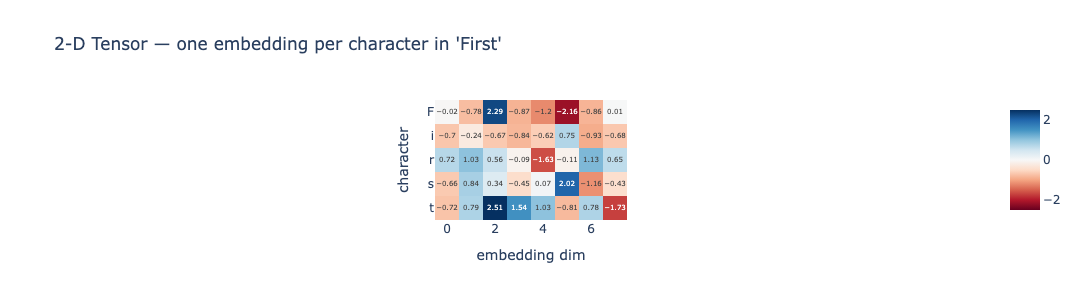

In [3]:
import plotly.express as px

chars = list("First")

# 1-D: just print it — a sequence of token IDs is not a chart, it's a mapping
print("Token IDs for 'First':")
for char, tid in zip(chars, sequence.tolist()):
    print(f"  '{char}' -> {tid}")

# 2-D: one sequence as a heatmap — rows are tokens, cols are embedding dims
fig = px.imshow(
    embedding_matrix.numpy(),
    text_auto=True,
    color_continuous_scale="RdBu",
    color_continuous_midpoint=0,
    labels={"x": "embedding dim", "y": "character"},
    title="2-D Tensor — one embedding per character in 'First'",
)
fig.update_yaxes(tickvals=list(range(5)), ticktext=chars)
fig.update_layout(height=300)
fig.show()

## Section 2 — Where do embeddings come from?

The random numbers in Section 1 were just noise. In a real model, embeddings
come from a **lookup table** — one row per token in the vocabulary.

At the start of training the table is random. But because it is stored as
`nn.Embedding`, PyTorch tracks its values as *parameters* and nudges them
during training until they become meaningful.

In [4]:
import torch.nn as nn

torch.manual_seed(1998)

# One row per token in the vocabulary, each represented by 8 numbers
embedding_table = nn.Embedding(num_embeddings=tok.vocab_size, embedding_dim=8)

# Look up 'First' using the tokenizer
sequence = torch.tensor(tok.encode("First"))
looked_up = embedding_table(sequence)

print(
    f"embedding_table weight shape: {embedding_table.weight.shape}  — full table (vocab, d_model)"
)
print(
    f"looked_up shape:              {looked_up.shape}               — just 'First' (seq_len, d_model)"
)

embedding_table weight shape: torch.Size([65, 8])  — full table (vocab, d_model)
looked_up shape:              torch.Size([5, 8])               — just 'First' (seq_len, d_model)


### A batch is just multiple sequences stacked together

Feed the model one sequence at a time and it learns slowly — GPUs are built
to process many things in parallel. So we stack sequences into a **batch**:
a 3-D tensor of shape `(batch, seq_len, d_model)`.

In [5]:
# Two different sequences from Shakespeare
seq_a = torch.tensor(tok.encode("First"))  # F, i, r, s, t
seq_b = torch.tensor(tok.encode("Befor"))  # B, e, f, o, r

batch_ids = torch.stack([seq_a, seq_b])  # (2, 5)
batch_embeddings = embedding_table(batch_ids)  # (2, 5, 8)

print(f"batch_ids shape:        {batch_ids.shape}     — (batch, seq_len)")
print(f"batch_embeddings shape: {batch_embeddings.shape}  — (batch, seq_len, d_model)")

batch_ids shape:        torch.Size([2, 5])     — (batch, seq_len)
batch_embeddings shape: torch.Size([2, 5, 8])  — (batch, seq_len, d_model)


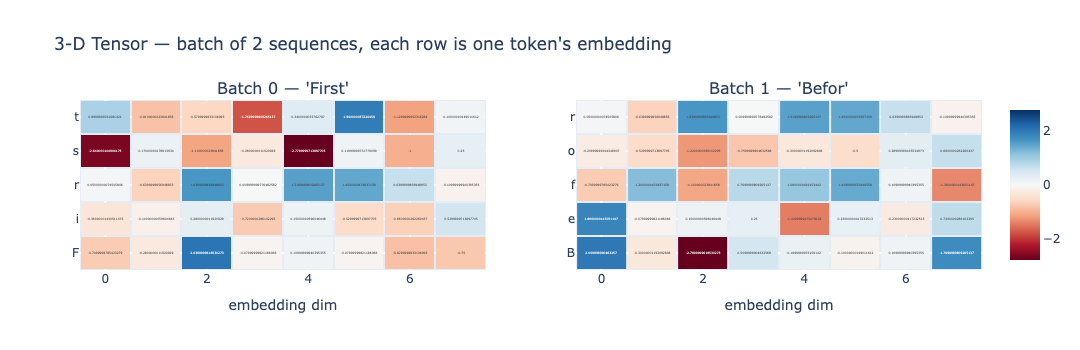

In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=2, subplot_titles=("Batch 0 — 'First'", "Batch 1 — 'Befor'")
)

for i, word in enumerate(["First", "Befor"]):
    data = batch_embeddings[i].detach().round(decimals=2).numpy()
    fig.add_trace(
        go.Heatmap(
            z=data,
            text=data,
            texttemplate="%{text}",
            colorscale="RdBu",
            zmid=0,
            showscale=(i == 1),
            xgap=2,
            ygap=2,
        ),
        row=1,
        col=i + 1,
    )
    fig.update_yaxes(tickvals=list(range(5)), ticktext=list(word), row=1, col=i + 1)
    fig.update_xaxes(title_text="embedding dim", row=1, col=i + 1)

fig.update_layout(
    title="3-D Tensor — batch of 2 sequences, each row is one token's embedding",
    height=350,
)
fig.show()

### The full 3-D tensor — sequences stacked as layers

The side-by-side view treats the two sequences as separate objects.
The 3-D view below shows them as they actually exist in memory: **two layers
of the same tensor**, stacked along a batch axis.

Each flat layer is a 2-D matrix — rows are token positions (characters),
columns are embedding dimensions.  Colour shows the value at each cell,
exactly as in the heatmaps above.  The depth axis is the batch dimension:
`tensor[0]` is the bottom layer, `tensor[1]` is the top.

This is the `(batch, seq_len, d_model)` shape made concrete — rotate it.

In [ ]:
import numpy as np

words = ["First", "Befor"]
fig = go.Figure()

for b, word in enumerate(words):
    data = batch_embeddings[b].detach().round(decimals=2).numpy()  # (5, 8)
    z_offset = b * 1.5  # vertical gap between layers

    xi = np.arange(data.shape[1])  # embedding dims  0..7
    yi = np.arange(data.shape[0])  # token positions 0..4
    X, Y = np.meshgrid(xi, yi)  # both (5, 8)
    Z = np.full_like(X, z_offset, dtype=float)  # flat layer at z=z_offset

    fig.add_trace(
        go.Surface(
            x=X,
            y=Y,
            z=Z,
            surfacecolor=data,
            colorscale="RdBu",
            cmid=0,
            showscale=(b == len(words) - 1),
            opacity=0.9,
            name=f"batch {b} — {word!r}",
        )
    )

fig.update_layout(
    title="3-D Tensor — shape (batch=2, seq_len=5, d_model=8)",
    scene=dict(
        xaxis=dict(title="embedding dim", tickvals=list(range(8))),
        yaxis=dict(
            title="token",
            tickvals=list(range(5)),
            ticktext=list("First"),
        ),
        zaxis=dict(
            title="batch",
            tickvals=[0, 1.5],
            ticktext=["batch 0 — 'First'", "batch 1 — 'Befor'"],
        ),
        camera=dict(eye=dict(x=1.5, y=-1.5, z=1.2)),
    ),
    height=550,
)
fig.show()